# 04 - Benchmarks

Comparaciones contra archivos USGS corregidos y salidas SeismoMatch disponibles en `examples/data/benchmark`. Para escalamiento se reporta el rango de control `0.2-2.0 s`, consistente con el benchmark academico usado en los ejemplos.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from signalprocessor.benchmark import batch_usgs_benchmark, compare_scaling_to_seismomatch, summarize_records
from signalprocessor.io import read_motion, read_target_spectrum
from signalprocessor.matching import MatchingConfig, match_spectrum
from signalprocessor.metrics import cumulative_arias, integrate_motion
from signalprocessor.recommendation import recommend_correction_method
from signalprocessor.spectra import fourier_amplitude_spectrum, response_spectrum


## Benchmark de correccion contra USGS

In [2]:
benchmark_root = ROOT / 'examples/data/benchmark'
usgs_table = batch_usgs_benchmark(benchmark_root)
usgs_table


,name,pga_ratio,rms_acc_error,notes
0,CCSP.HNE.._u,0.898962,0.010236,baseline_0_hp_0.1318_cheby2
1,CCSP.HNN.._u,0.968247,0.009336,baseline_0_hp_0.1_bessel
2,CCSP.HNZ.._u,0.903897,0.025956,baseline_0_hp_0.0879


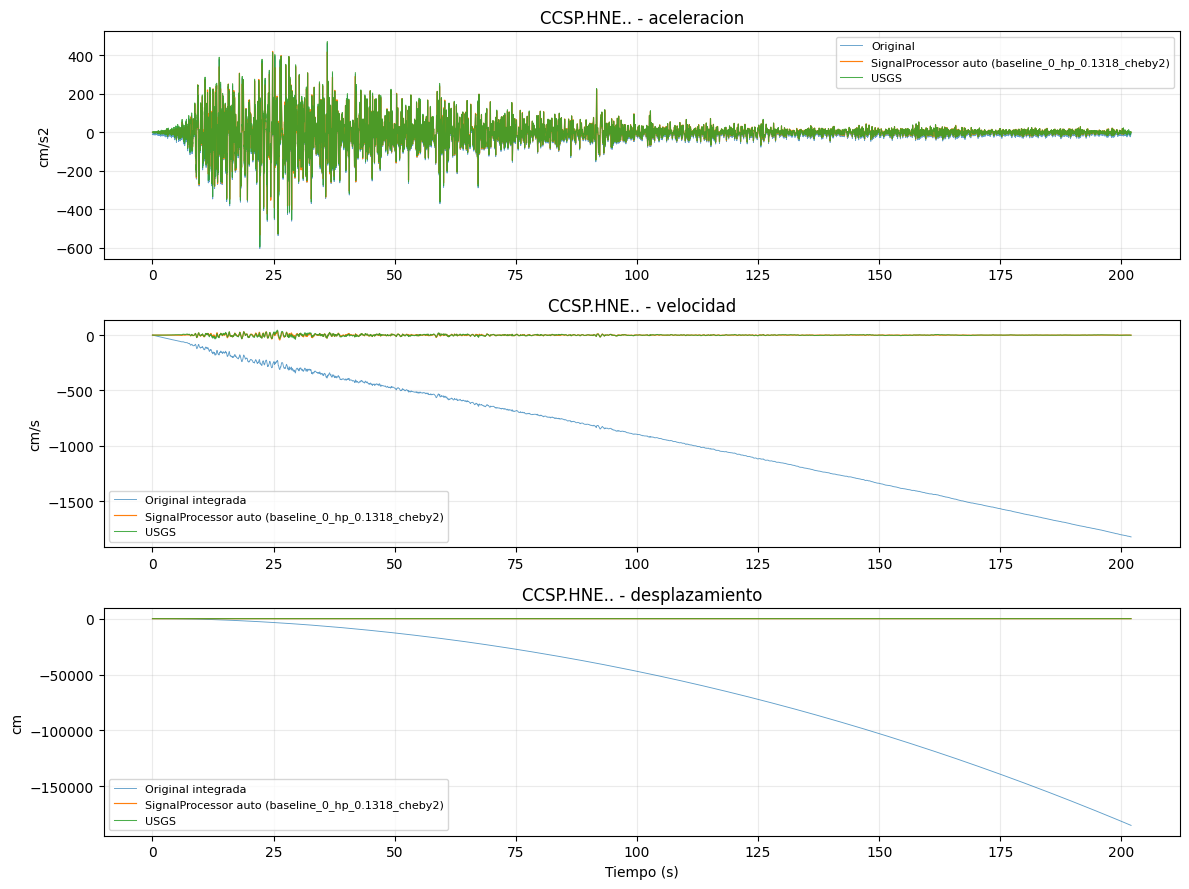

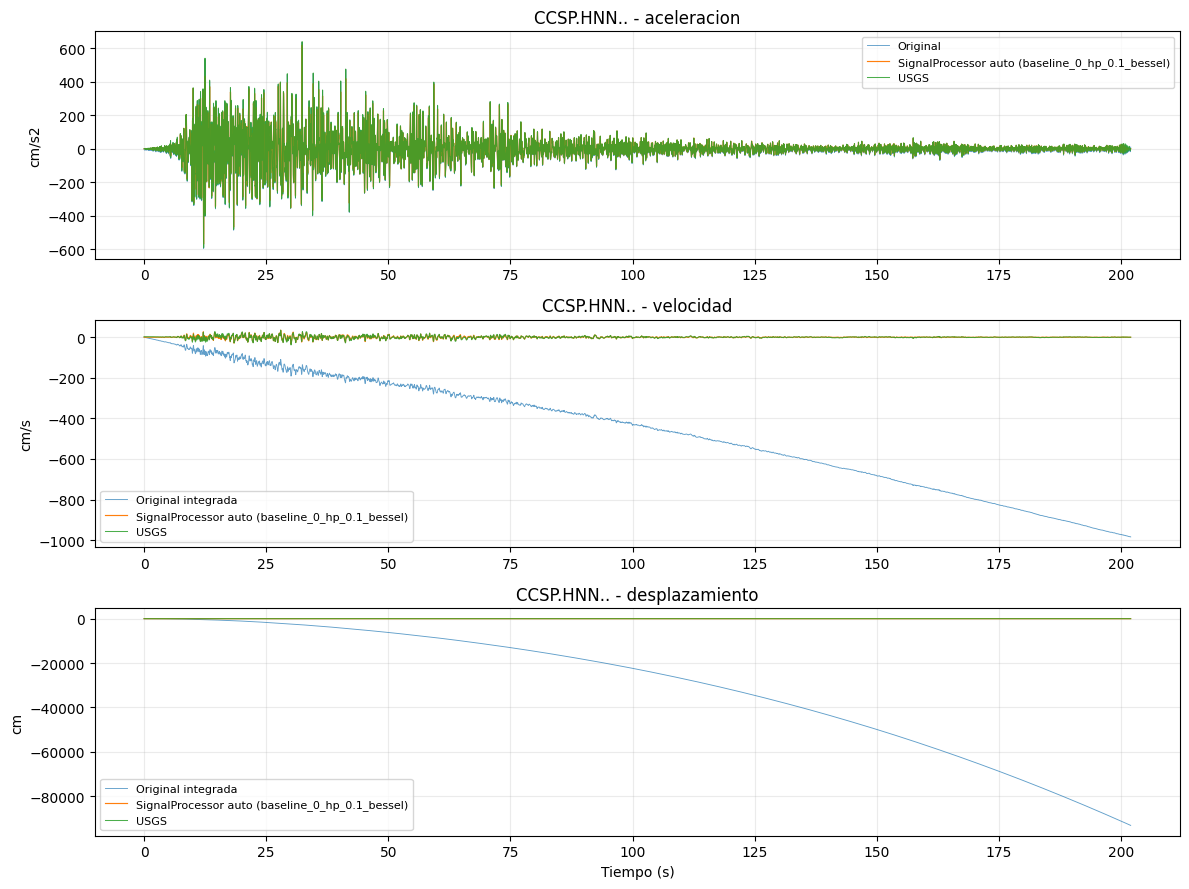

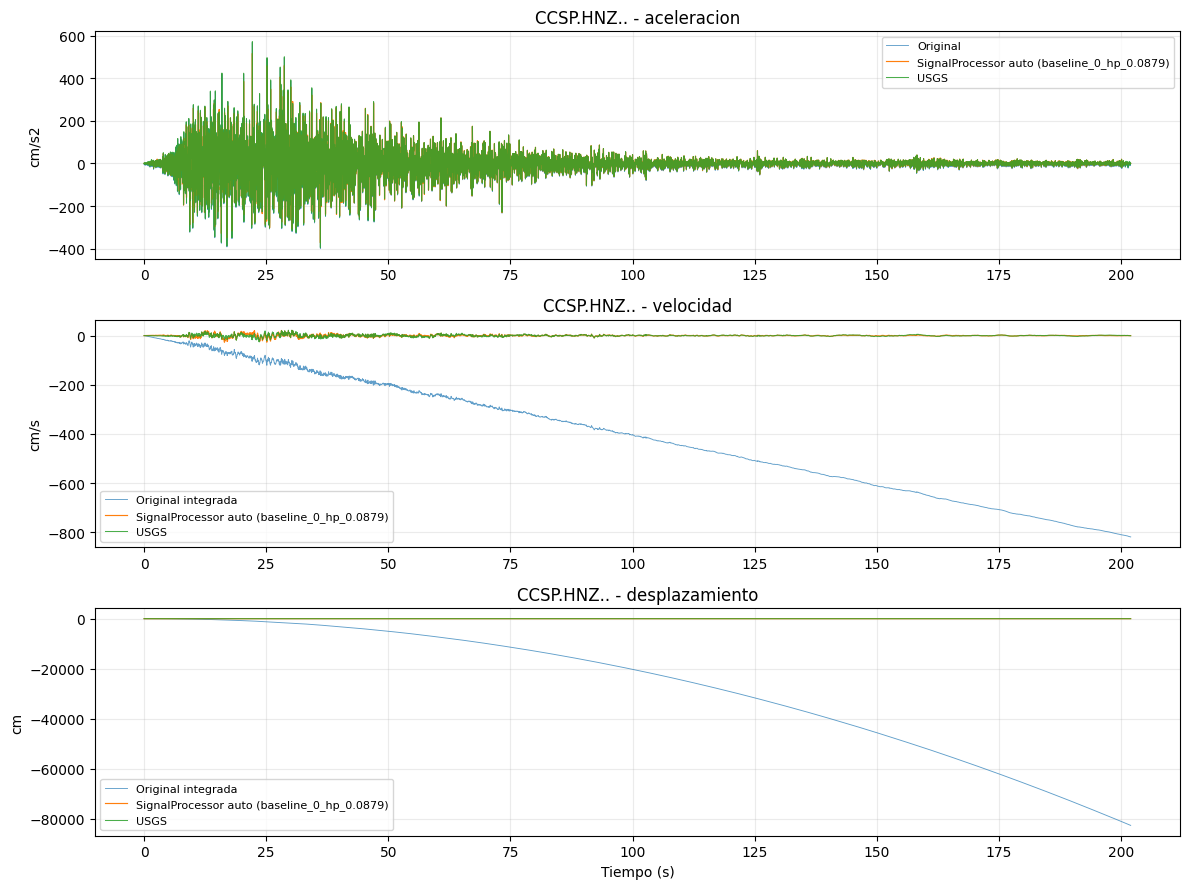

In [3]:
def plot_correction_case(component):
    raw = read_motion(benchmark_root / 'uncorrected_motion' / f'{component}_u.smc')
    usgs_acc = read_motion(benchmark_root / 'corrected_motion' / f'{component}_a.smc', units='cm/s^2')
    usgs_vel = read_motion(benchmark_root / 'corrected_motion' / f'{component}_v.smc', units='cm/s^2')
    usgs_disp = read_motion(benchmark_root / 'corrected_motion' / f'{component}_d.smc', units='cm/s^2')

    recommendation = recommend_correction_method(raw, t_min=0.05, t_max=3.0)
    project = recommendation.best.result
    project_label = f'SignalProcessor auto ({recommendation.best.name})'
    project_acc = project.record.as_units('cm/s^2')
    raw_vel, raw_disp = integrate_motion(raw.acceleration_si(), raw.dt)

    n_acc = min(raw.npts, project_acc.npts, usgs_acc.npts)
    n_vel = min(raw.npts, project.velocity.size, usgs_vel.npts)
    n_disp = min(raw.npts, project.displacement.size, usgs_disp.npts)

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)
    axes[0].plot(raw.time[:n_acc], raw.as_units('cm/s^2').acceleration[:n_acc], lw=0.65, alpha=0.7, label='Original')
    axes[0].plot(project_acc.time[:n_acc], project_acc.acceleration[:n_acc], lw=0.85, label=project_label)
    axes[0].plot(usgs_acc.time[:n_acc], usgs_acc.acceleration[:n_acc], lw=0.75, alpha=0.85, label='USGS')
    axes[0].set_title(f'{component} - aceleracion')
    axes[0].set_ylabel('cm/s2')

    axes[1].plot(raw.time[:n_vel], raw_vel[:n_vel] * 100.0, lw=0.65, alpha=0.7, label='Original integrada')
    axes[1].plot(project.record.time[:n_vel], project.velocity[:n_vel] * 100.0, lw=0.85, label=project_label)
    axes[1].plot(usgs_vel.time[:n_vel], usgs_vel.acceleration[:n_vel], lw=0.75, alpha=0.85, label='USGS')
    axes[1].set_title(f'{component} - velocidad')
    axes[1].set_ylabel('cm/s')

    axes[2].plot(raw.time[:n_disp], raw_disp[:n_disp] * 100.0, lw=0.65, alpha=0.7, label='Original integrada')
    axes[2].plot(project.record.time[:n_disp], project.displacement[:n_disp] * 100.0, lw=0.85, label=project_label)
    axes[2].plot(usgs_disp.time[:n_disp], usgs_disp.acceleration[:n_disp], lw=0.75, alpha=0.85, label='USGS')
    axes[2].set_title(f'{component} - desplazamiento')
    axes[2].set_ylabel('cm')
    axes[2].set_xlabel('Tiempo (s)')

    for ax in axes:
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    fig.tight_layout()
    return fig

for component in ['CCSP.HNE..', 'CCSP.HNN..', 'CCSP.HNZ..']:
    plot_correction_case(component)


## Benchmark de escalamiento contra SeismoMatch


In [4]:
target = ROOT / 'examples/data/response_spectrum/EPU_475.csv'
pairs = [
    ('ATICOEW.csv', 'ATICOEW.txt'),
    ('ATICONS.csv', 'ATICONS.txt'),
    ('LIMANS.csv', 'LIMANS.txt'),
    ('LIMAEW.csv', 'LIMAEW..txt'),
]
rows = []
for seed_name, ref_name in pairs:
    for matched in [False, True]:
        rows.append(compare_scaling_to_seismomatch(
            benchmark_root / 'unscaled_motion' / seed_name,
            target,
            benchmark_root / 'scaled_motion' / ref_name,
            t_min=0.2,
            t_max=2.0,
            matched=matched,
        ))
scaling_table = pd.DataFrame(rows)
scaling_table


,name,method,factor,max_abs_error,rms_log_error,seismomatch_rms_log_error,time_series_rms_vs_seismomatch
0,ATICOEW,linear,0.653853,1.498769,0.517697,0.020645,0.026481
1,ATICOEW,matched_hybrid,NaN,0.042995,0.017871,0.020645,0.025602
2,ATICONS,linear,0.601198,0.865293,0.488787,0.112341,0.034028
3,ATICONS,matched_hybrid,NaN,0.049749,0.025595,0.112341,0.032442
4,LIMANS,linear,1.061648,0.791750,0.314208,0.036721,0.051429
5,LIMANS,matched_hybrid,NaN,0.041887,0.026616,0.036721,0.051094
6,LIMAEW,linear,0.975773,1.321125,0.407317,0.082276,0.047338
7,LIMAEW,matched_hybrid,NaN,0.044317,0.026045,0.082276,0.045663


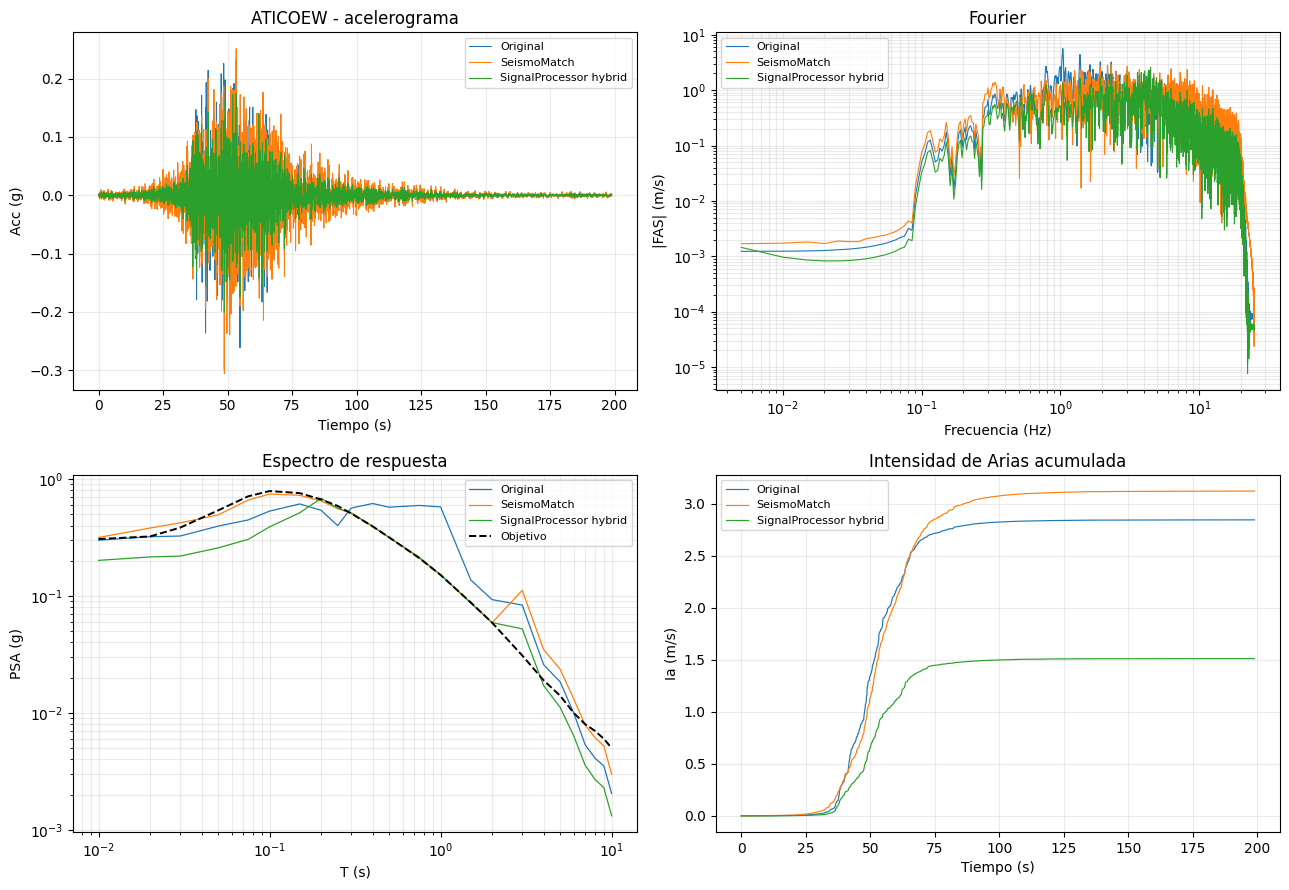

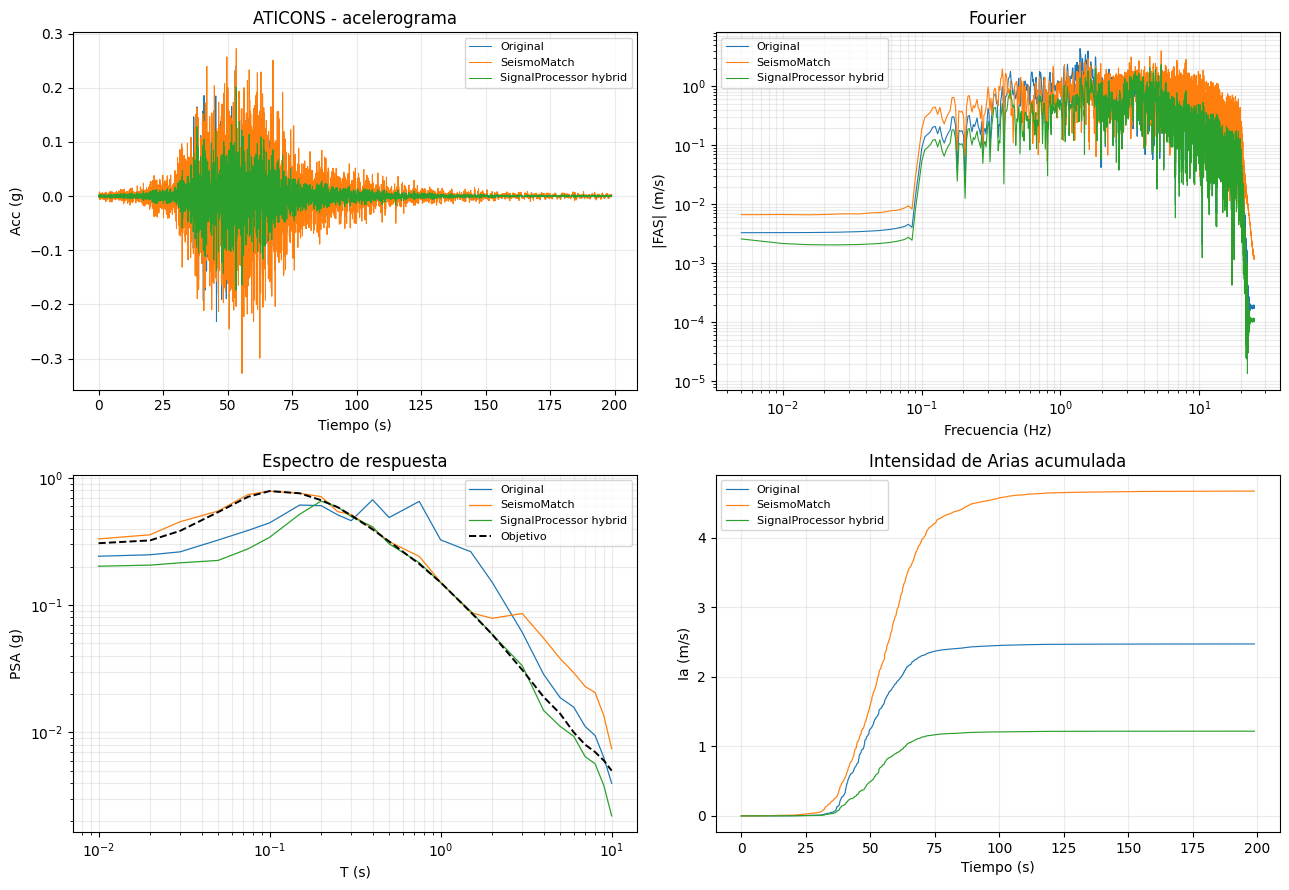

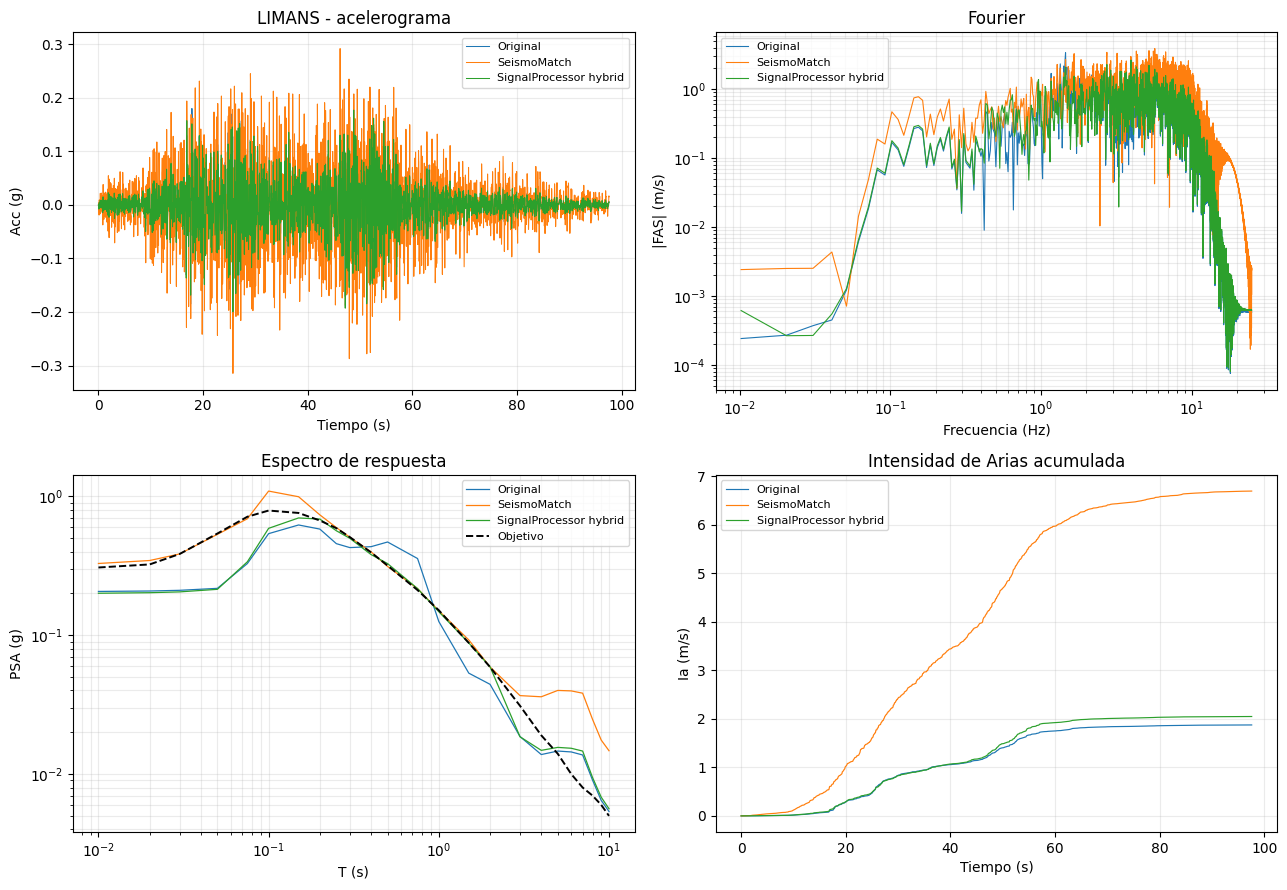

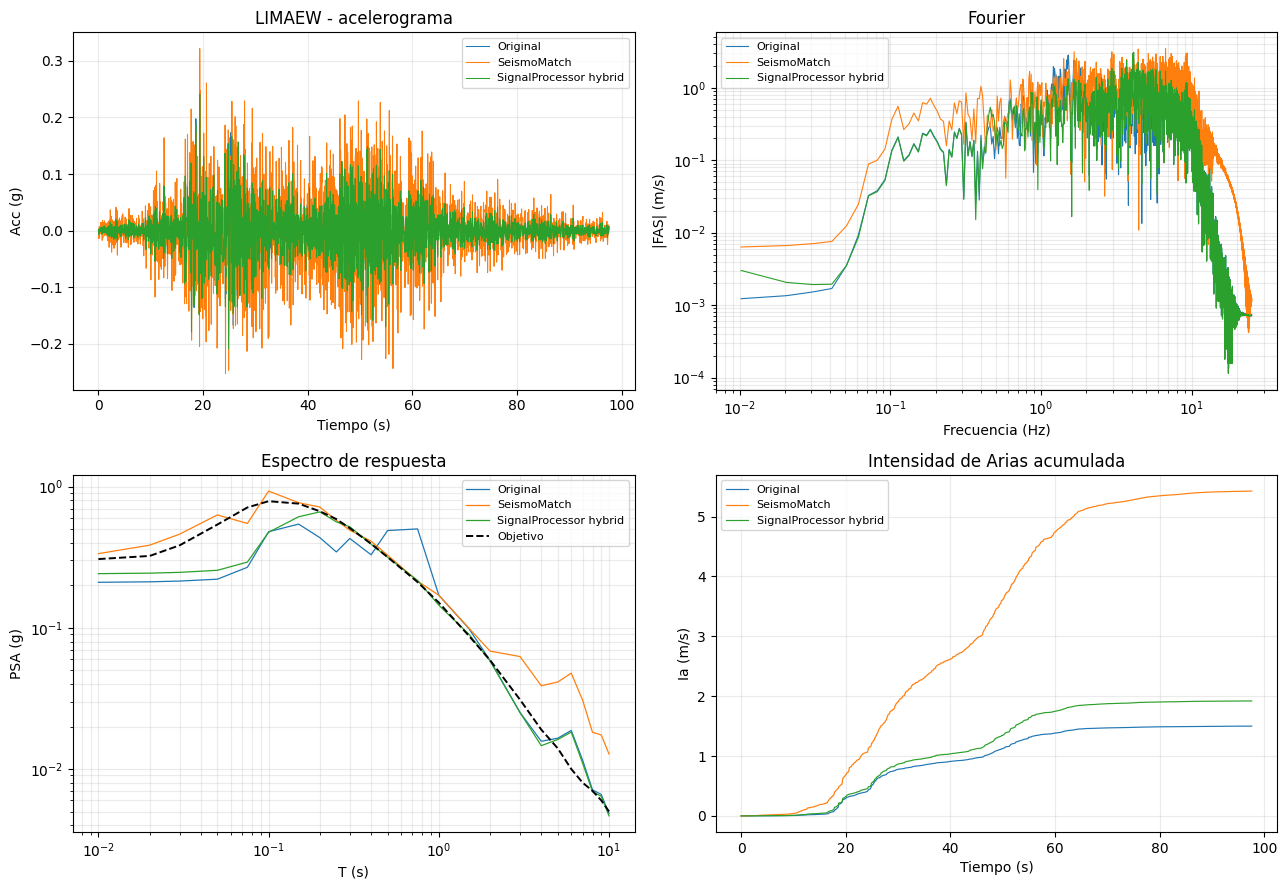

In [5]:
target_spectrum = read_target_spectrum(target)
match_cfg = MatchingConfig(method='hybrid', max_iterations=15, relaxation=0.35, t_min=0.2, t_max=2.0)

def plot_scaling_case(seed_name, seismomatch_name):
    original = read_motion(benchmark_root / 'unscaled_motion' / seed_name)
    seismomatch = read_motion(benchmark_root / 'scaled_motion' / seismomatch_name)
    project = match_spectrum(original, target_spectrum, match_cfg).record

    series = [
        ('Original', original.as_units('g')),
        ('SeismoMatch', seismomatch.as_units('g')),
        ('SignalProcessor hybrid', project.as_units('g')),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    ax_acc, ax_fas, ax_spec, ax_arias = axes.ravel()

    for label, rec in series:
        ax_acc.plot(rec.time, rec.acceleration, lw=0.75, label=label)

        freqs, amp = fourier_amplitude_spectrum(rec)
        mask = freqs > 0.0
        ax_fas.loglog(freqs[mask], amp[mask], lw=0.8, label=label)

        spec = response_spectrum(rec, target_spectrum.periods, output_units='g', damping=target_spectrum.damping)
        ax_spec.loglog(spec.periods, spec.sa, lw=0.9, label=label)

        arias = cumulative_arias(rec.acceleration_si(), rec.dt)
        ax_arias.plot(rec.time, arias, lw=0.85, label=label)

    ax_spec.loglog(target_spectrum.periods, target_spectrum.sa, 'k--', lw=1.4, label='Objetivo')

    ax_acc.set_title(f'{Path(seed_name).stem} - acelerograma')
    ax_acc.set_xlabel('Tiempo (s)')
    ax_acc.set_ylabel('Acc (g)')

    ax_fas.set_title('Fourier')
    ax_fas.set_xlabel('Frecuencia (Hz)')
    ax_fas.set_ylabel('|FAS| (m/s)')

    ax_spec.set_title('Espectro de respuesta')
    ax_spec.set_xlabel('T (s)')
    ax_spec.set_ylabel('PSA (g)')

    ax_arias.set_title('Intensidad de Arias acumulada')
    ax_arias.set_xlabel('Tiempo (s)')
    ax_arias.set_ylabel('Ia (m/s)')

    for ax in axes.ravel():
        ax.grid(True, which='both', alpha=0.25)
        ax.legend(fontsize=8)
    fig.tight_layout()
    return fig

for seed_name, ref_name in pairs:
    plot_scaling_case(seed_name, ref_name)


## Resumen de registros disponibles

In [6]:
summarize_records(sorted((ROOT / 'examples/data/motion').glob('*.csv')))


,name,dt,npts,duration,pga_g,pgv_mps,arias_mps,d5_95_s
0,ATICOEW,0.020,9945,198.880,0.298430,0.221603,2.846948,35.848512
1,ATICONS,0.020,9945,198.880,0.240923,0.294730,2.471370,36.030638
2,LIMAEW,0.020,4879,97.560,0.209421,0.166462,1.499592,44.512603
3,LIMANS,0.020,4879,97.560,0.205856,0.156415,1.875107,45.879512
4,TARAPACAEW,0.005,37800,188.995,0.170867,0.089207,0.623940,32.001808
5,TARAPACANS,0.005,37800,188.995,0.207969,0.084950,0.605228,39.390238
